# Zameen.com House Price Prediction - ML Pipeline
**Student:** Menahil Suleman &nbsp;|&nbsp; **Registration No:** FA24-BDS-029

**Program:** Bachelor of Data Science &nbsp;|&nbsp; **University:** COMSATS University Islamabad, Virtual Campus

**Tasks:** CLO-2 Preprocessing | CLO-3 Model Development | CLO-4 Evaluation | CLO-5 Prediction System

This notebook loads the dataset produced by `zameen_scraper.ipynb` and performs the full machine learning pipeline: preprocessing, model training, evaluation, cross-validation, and an interactive house price prediction system.

**Prerequisite:** Run `zameen_scraper.ipynb` first and place `zameen_data.csv` in the same folder as this notebook.

---
# Task 2: Data Preprocessing and Feature Engineering
Clean the scraped dataset, handle missing values, remove duplicates, encode categorical variables, and prepare the feature matrix for model training.

### Step 1: Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

df = pd.read_csv("zameen_data.csv")

print("Shape:", df.shape)
print("\nColumn Types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (300, 15)

Column Types:
city                 object
location             object
price_text           object
price_pkr             int64
bedrooms            float64
bathrooms           float64
size_text            object
size_sqft             int64
property_type        object
built_year          float64
parking_spaces      float64
servant_quarters    float64
store_rooms         float64
kitchens            float64
drawing_rooms       float64
dtype: object

First 5 rows:


,city,location,price_text,price_pkr,bedrooms,bathrooms,size_text,size_sqft,property_type,built_year,parking_spaces,servant_quarters,store_rooms,kitchens,drawing_rooms
0,Islamabad,"E-11, Islamabad",13 Crore,130000000,9.0,7.0,16 Marla,3600,House,NaN,NaN,NaN,NaN,NaN,NaN
1,Islamabad,"Jinnah Gardens Phase 1, Jinnah Gardens",3.15 Crore,31500000,4.0,5.0,7 Marla,1575,House,2025.0,1.0,NaN,NaN,NaN,NaN
2,Islamabad,"DHA Defence Phase 2, DHA Defence",10.5 Crore,105000000,5.0,6.0,1 Kanal,4500,House,2026.0,3.0,1.0,2.0,2.0,NaN
3,Islamabad,"Top City 1 - Block B, Top City 1",8.5 Crore,85000000,8.0,7.0,1 Kanal,4500,House,NaN,NaN,1.0,1.0,2.0,NaN
4,Islamabad,"DHA Defence Phase 2, DHA Defence",14.9 Crore,149000000,5.0,6.0,1 Kanal,4500,House,2026.0,3.0,2.0,2.0,2.0,NaN


### Step 2: Handle Missing Values

Columns with more than 50% missing values are dropped. Numerical columns are filled with the column median and categorical columns with the column mode.

In [2]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df  = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
print(missing_df[missing_df["Missing Count"] > 0])

threshold = 0.5
df = df.dropna(thresh=int(threshold * len(df)), axis=1)
print(f"\nColumns after dropping columns with over 50 percent missing: {df.columns.tolist()}")

num_cols = df.select_dtypes(include=["float64", "int64"]).columns
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

cat_cols = df.select_dtypes(include=["object"]).columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing values after treatment:")
print(df.isnull().sum())

                  Missing Count  Missing %
bedrooms                      9   3.000000
bathrooms                    14   4.666667
property_type                 1   0.333333
built_year                   83  27.666667
parking_spaces              111  37.000000
servant_quarters            116  38.666667
store_rooms                 124  41.333333
kitchens                     56  18.666667
drawing_rooms               282  94.000000

Columns after dropping columns with over 50 percent missing: ['city', 'location', 'price_text', 'price_pkr', 'bedrooms', 'bathrooms', 'size_text', 'size_sqft', 'property_type', 'built_year', 'parking_spaces', 'servant_quarters', 'store_rooms', 'kitchens']

Missing values after treatment:
city                0
location            0
price_text          0
price_pkr           0
bedrooms            0
bathrooms           0
size_text           0
size_sqft           0
property_type       0
built_year          0
parking_spaces      0
servant_quarters    0
store_rooms     

### Step 3: Remove Duplicate Records

Duplicate rows can introduce bias into model training and inflate performance metrics.

In [3]:
before = len(df)
df.drop_duplicates(inplace=True)
after  = len(df)

print(f"Rows before       : {before}")
print(f"Rows after        : {after}")
print(f"Duplicates removed: {before - after}")

Rows before       : 300
Rows after        : 299
Duplicates removed: 1


### Step 4: Encode Categorical Variables

Machine learning models require numerical input. Label Encoding is applied to the `city` and `location` columns. Raw string columns (`price_text`, `size_text`) are dropped as their numeric equivalents already exist.

In [4]:
le = LabelEncoder()

drop_raw = [col for col in ["price_text", "size_text"] if col in df.columns]
df.drop(columns=drop_raw, inplace=True)

cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns to encode:", cat_cols)

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f"  '{col}' encoded into {df[col].nunique()} unique numeric values")

print("\nDataset after encoding:")
df.head()

Categorical columns to encode: ['city', 'location', 'property_type']
  'city' encoded into 1 unique numeric values
  'location' encoded into 129 unique numeric values
  'property_type' encoded into 4 unique numeric values

Dataset after encoding:


,city,location,price_pkr,bedrooms,bathrooms,size_sqft,property_type,built_year,parking_spaces,servant_quarters,store_rooms,kitchens
0,0,41,130000000,9.0,7.0,3600,2,2025.0,2.0,1.0,1.0,2.0
1,0,97,31500000,4.0,5.0,1575,2,2025.0,1.0,1.0,1.0,2.0
2,0,32,105000000,5.0,6.0,4500,2,2026.0,3.0,1.0,2.0,2.0
3,0,123,85000000,8.0,7.0,4500,2,2025.0,2.0,1.0,1.0,2.0
4,0,32,149000000,5.0,6.0,4500,2,2026.0,3.0,2.0,2.0,2.0


### Step 5: Define Features and Target

In [5]:
target = "price_pkr"

X = df.drop(columns=[target])
y = df[target]

print("Features (X):", X.columns.tolist())
print("Target   (y):", target)
print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features (X): ['city', 'location', 'bedrooms', 'bathrooms', 'size_sqft', 'property_type', 'built_year', 'parking_spaces', 'servant_quarters', 'store_rooms', 'kitchens']
Target   (y): price_pkr

X shape: (299, 11)
y shape: (299,)


### Step 6: Train-Test Split

The dataset is split into 80% training and 20% testing. This ensures the model is evaluated on data it has never seen during training.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set :", X_train.shape)
print("Testing set  :", X_test.shape)
print(f"\n80% Train: {len(X_train)} rows")
print(f"20% Test : {len(X_test)} rows")

Training set : (239, 11)
Testing set  : (60, 11)

80% Train: 239 rows
20% Test : 60 rows


### Step 7: Final Dataset Summary

In [7]:
print("Final Dataset Summary")
print(f"Total rows     : {len(df)}")
print(f"Total features : {X.shape[1]}")
print(f"Target column  : price_pkr")
print(f"\nFeature statistics:")
print(X.describe())

Final Dataset Summary
Total rows     : 299
Total features : 11
Target column  : price_pkr

Feature statistics:
        city   location    bedrooms   bathrooms     size_sqft  property_type  \
count  299.0  299.00000  299.000000  299.000000    299.000000     299.000000   
mean     0.0   65.83612    4.461538    4.635452   2999.876254       1.712375   
std      0.0   37.17386    1.914540    1.741002   3217.587241       0.467982   
min      0.0    0.00000    1.000000    1.000000    472.000000       0.000000   
25%      0.0   32.00000    3.000000    3.000000   1125.000000       1.000000   
50%      0.0   60.00000    5.000000    5.000000   2250.000000       2.000000   
75%      0.0   97.00000    5.000000    6.000000   4005.000000       2.000000   
max      0.0  128.00000   10.000000    7.000000  22500.000000       3.000000   

        built_year  parking_spaces  servant_quarters  store_rooms     kitchens  
count   299.000000      299.000000        299.000000   299.000000   299.000000  
mean  

---
# Task 3: House Price Prediction
End-to-end ML pipeline using the cleaned Zameen.com dataset. Six models are trained on the same data split for a fair comparison.

### Step 1: Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

print("Libraries imported successfully.")

Libraries imported successfully.


### Step 2: Load and Inspect Dataset

In [9]:
df = pd.read_csv("zameen_data.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (300, 15)

Columns: ['city', 'location', 'price_text', 'price_pkr', 'bedrooms', 'bathrooms', 'size_text', 'size_sqft', 'property_type', 'built_year', 'parking_spaces', 'servant_quarters', 'store_rooms', 'kitchens', 'drawing_rooms']

Data Types:
city                 object
location             object
price_text           object
price_pkr             int64
bedrooms            float64
bathrooms           float64
size_text            object
size_sqft             int64
property_type        object
built_year          float64
parking_spaces      float64
servant_quarters    float64
store_rooms         float64
kitchens            float64
drawing_rooms       float64
dtype: object

First 5 rows:


,city,location,price_text,price_pkr,bedrooms,bathrooms,size_text,size_sqft,property_type,built_year,parking_spaces,servant_quarters,store_rooms,kitchens,drawing_rooms
0,Islamabad,"E-11, Islamabad",13 Crore,130000000,9.0,7.0,16 Marla,3600,House,NaN,NaN,NaN,NaN,NaN,NaN
1,Islamabad,"Jinnah Gardens Phase 1, Jinnah Gardens",3.15 Crore,31500000,4.0,5.0,7 Marla,1575,House,2025.0,1.0,NaN,NaN,NaN,NaN
2,Islamabad,"DHA Defence Phase 2, DHA Defence",10.5 Crore,105000000,5.0,6.0,1 Kanal,4500,House,2026.0,3.0,1.0,2.0,2.0,NaN
3,Islamabad,"Top City 1 - Block B, Top City 1",8.5 Crore,85000000,8.0,7.0,1 Kanal,4500,House,NaN,NaN,1.0,1.0,2.0,NaN
4,Islamabad,"DHA Defence Phase 2, DHA Defence",14.9 Crore,149000000,5.0,6.0,1 Kanal,4500,House,2026.0,3.0,2.0,2.0,2.0,NaN


In [10]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nBasic statistics:")
df.describe()

Missing values per column:
city                  0
location              0
price_text            0
price_pkr             0
bedrooms              9
bathrooms            14
size_text             0
size_sqft             0
property_type         1
built_year           83
parking_spaces      111
servant_quarters    116
store_rooms         124
kitchens             56
drawing_rooms       282
dtype: int64

Basic statistics:


,price_pkr,bedrooms,bathrooms,size_sqft,built_year,parking_spaces,servant_quarters,store_rooms,kitchens,drawing_rooms
count,3.000000e+02,291.000000,286.000000,300.000000,217.000000,189.000000,184.000000,176.000000,244.000000,18.000000
mean,9.379908e+07,4.443299,4.618881,2993.626667,2023.041475,2.650794,1.277174,1.267045,9.987705,2.222222
std,1.430013e+08,1.938551,1.778485,3214.025495,4.979879,3.743755,0.516737,0.492509,129.530792,1.437136
min,7.500000e+04,1.000000,1.000000,472.000000,2000.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.382500e+07,3.000000,3.000000,1125.000000,2022.000000,1.000000,1.000000,1.000000,1.000000,2.000000
50%,4.575000e+07,5.000000,5.000000,2250.000000,2025.000000,2.000000,1.000000,1.000000,2.000000,2.000000
75%,9.937500e+07,5.000000,6.000000,4005.000000,2026.000000,3.000000,1.250000,1.250000,2.000000,2.000000
max,1.200000e+09,10.000000,7.000000,22500.000000,2029.000000,45.000000,4.000000,4.000000,2025.000000,6.000000


### Step 3: Data Cleaning

Features used: `location`, `bedrooms`, `bathrooms`, `size_sqft`, `property_type`

Target: `price_pkr`

Dropped: `price_text`, `size_text` (redundant string columns), `city` (single value, carries no predictive signal), and any detail-page columns that are fully empty after scraping (dropped automatically by the 50% missing threshold in Task 2).


In [11]:
df = df.drop(columns=["price_text", "size_text", "city"])

# Drop rows where core columns are missing
df = df.dropna(subset=["price_pkr", "size_sqft"])

# Drop columns that are entirely empty (e.g. detail-page fields that failed scraping)
df = df.dropna(axis=1, how="all")

# Fill all remaining numeric NaNs with column median
for col in df.select_dtypes(include=["float64", "int64"]).columns:
    df[col] = df[col].fillna(df[col].median())

# Fill all remaining string NaNs with column mode
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print(f"Shape after cleaning: {df.shape}")
print("Remaining nulls:", df.isnull().sum().sum())


Shape after cleaning: (300, 12)
Remaining nulls: 0


### Step 4: Outlier Removal

Extreme values at the 99th percentile are capped to reduce noise in model training.

In [12]:
price_cap = df["price_pkr"].quantile(0.99)
size_cap  = df["size_sqft"].quantile(0.99)

df = df[(df["price_pkr"] <= price_cap) & (df["size_sqft"] <= size_cap)]

print(f"Price cap : PKR {price_cap:,.0f}")
print(f"Size cap  : {size_cap:,.0f} sqft")
print(f"Shape after outlier removal: {df.shape}")

Price cap : PKR 700,200,000
Size cap  : 18,000 sqft
Shape after outlier removal: (296, 12)


### Step 5: Exploratory Data Analysis

Visual inspection of the price and size distributions to understand the data before modeling.

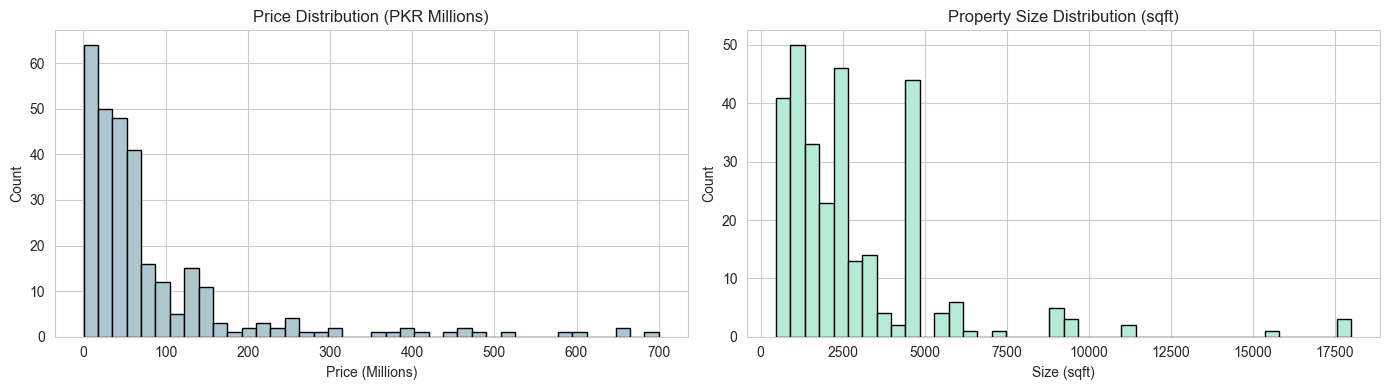

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["price_pkr"] / 1e6, bins=40, color="#AEC6CF", edgecolor="black")
axes[0].set_title("Price Distribution (PKR Millions)")
axes[0].set_xlabel("Price (Millions)")
axes[0].set_ylabel("Count")

axes[1].hist(df["size_sqft"], bins=40, color="#B5EAD7", edgecolor="black")
axes[1].set_title("Property Size Distribution (sqft)")
axes[1].set_xlabel("Size (sqft)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("distributions.png", dpi=150)
plt.show()

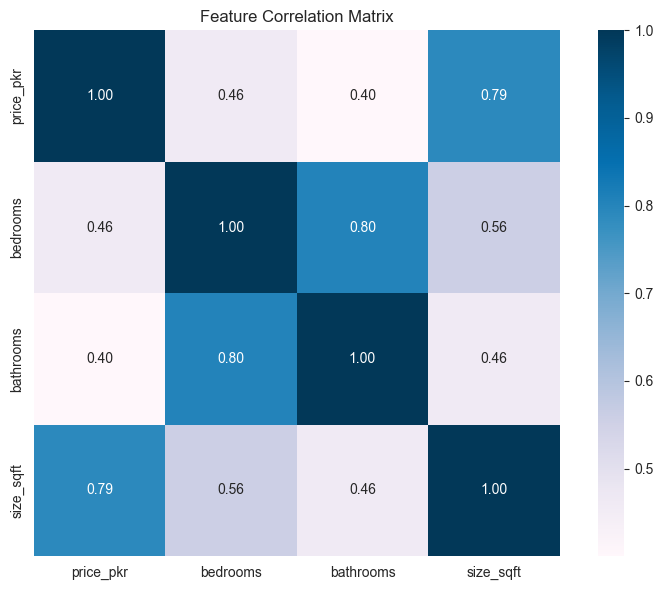

In [14]:
plt.figure(figsize=(8, 6))
corr_cols = [c for c in ["price_pkr", "property_type", "bedrooms", "bathrooms", "size_sqft"] if c in df.columns]
numeric_corr_cols = df[corr_cols].select_dtypes(include=["float64", "int64"]).columns.tolist()
corr = df[numeric_corr_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="PuBu", square=True)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("correlation.png", dpi=150)
plt.show()


### Step 6: Encode Categorical Features

The `location` and `property_type` columns are encoded numerically using Label Encoding. Both encoders are saved separately for use in the prediction system later.


In [15]:
location_encoder = LabelEncoder()
df["location"] = location_encoder.fit_transform(df["location"].astype(str))
print(f"Unique encoded locations    : {df['location'].nunique()}")

if "property_type" in df.columns:
    property_type_encoder = LabelEncoder()
    df["property_type"] = property_type_encoder.fit_transform(df["property_type"].astype(str))
    print(f"Unique encoded property types: {df['property_type'].nunique()}")

print(df.head())


Unique encoded locations    : 126
Unique encoded property types: 4
   location  price_pkr  bedrooms  bathrooms  size_sqft  property_type  \
0        41  130000000       9.0        7.0       3600              2   
1        94   31500000       4.0        5.0       1575              2   
2        32  105000000       5.0        6.0       4500              2   
3       120   85000000       8.0        7.0       4500              2   
4        32  149000000       5.0        6.0       4500              2   

   built_year  parking_spaces  servant_quarters  store_rooms  kitchens  \
0      2025.0             2.0               1.0          1.0       2.0   
1      2025.0             1.0               1.0          1.0       2.0   
2      2026.0             3.0               1.0          2.0       2.0   
3      2025.0             2.0               1.0          1.0       2.0   
4      2026.0             3.0               2.0          2.0       2.0   

   drawing_rooms  
0            2.0  
1          

### Step 7: Feature and Target Split

In [16]:
X = df.drop(columns=["price_pkr"])
y = df["price_pkr"]

print("Features:", X.columns.tolist())
print("X shape :", X.shape)
print("y shape :", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain rows: {len(X_train)}")
print(f"Test  rows: {len(X_test)}")

Features: ['location', 'bedrooms', 'bathrooms', 'size_sqft', 'property_type', 'built_year', 'parking_spaces', 'servant_quarters', 'store_rooms', 'kitchens', 'drawing_rooms']
X shape : (296, 11)
y shape : (296,)

Train rows: 236
Test  rows: 60


### Step 8: Evaluation Helper Function

A single function is used to train and evaluate each model consistently, returning MAE, RMSE, and R² Score.

In [17]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    mae   = mean_absolute_error(y_te, preds)
    rmse  = np.sqrt(mean_squared_error(y_te, preds))
    r2    = r2_score(y_te, preds)
    print(f"\n  {name}")
    print(f"  MAE  : PKR {mae:,.0f}")
    print(f"  RMSE : PKR {rmse:,.0f}")
    print(f"  R2   : {r2:.4f}")
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2, "preds": preds}

### Step 9: Linear Regression (Baseline)

Linear Regression assumes a straight-line relationship between features and price. It serves as the performance baseline.

In [18]:
lr_result = evaluate("Linear Regression", LinearRegression(), X_train, y_train, X_test, y_test)


  Linear Regression
  MAE  : PKR 39,835,569
  RMSE : PKR 71,827,094
  R2   : 0.3839


### Step 10: Decision Tree Regressor

Decision Trees split the data on feature thresholds to create a tree of decision rules. `max_depth=8` limits overfitting.

In [19]:
dt_result = evaluate("Decision Tree", DecisionTreeRegressor(max_depth=8, random_state=42), X_train, y_train, X_test, y_test)


  Decision Tree
  MAE  : PKR 39,611,504
  RMSE : PKR 88,279,430
  R2   : 0.0694


### Step 11: Random Forest Regressor

Random Forest builds 200 decision trees and averages their predictions, reducing variance and overfitting compared to a single tree.

In [20]:
rf_result = evaluate(
    "Random Forest",
    RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    X_train, y_train, X_test, y_test
)


  Random Forest
  MAE  : PKR 29,655,248
  RMSE : PKR 61,774,403
  R2   : 0.5443


### Step 12: Gradient Boosting Regressor

Gradient Boosting trains trees sequentially, each one correcting the errors of the previous. A low learning rate of 0.05 improves generalization.

In [21]:
gb_result = evaluate(
    "Gradient Boosting",
    GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42),
    X_train, y_train, X_test, y_test
)


  Gradient Boosting
  MAE  : PKR 31,753,566
  RMSE : PKR 69,262,613
  R2   : 0.4271


### Step 13: XGBoost Regressor

XGBoost is a regularized gradient boosting implementation known for high performance. Subsampling and column sampling help prevent overfitting.

In [22]:
xgb_result = evaluate(
    "XGBoost",
    XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                 subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0),
    X_train, y_train, X_test, y_test
)


  XGBoost
  MAE  : PKR 22,811,080
  RMSE : PKR 40,691,360
  R2   : 0.8023


### Step 14: CatBoost Regressor

CatBoost is a gradient boosting library optimized for categorical features. It uses ordered boosting to reduce prediction shift.

In [23]:
cat_result = evaluate(
    "CatBoost",
    CatBoostRegressor(iterations=300, learning_rate=0.05, depth=6, random_seed=42, verbose=0),
    X_train, y_train, X_test, y_test
)


  CatBoost
  MAE  : PKR 18,582,883
  RMSE : PKR 29,650,324
  R2   : 0.8950


### Step 15: Model Comparison Table

In [24]:
results = pd.DataFrame([
    {k: v for k, v in r.items() if k != "preds"}
    for r in [lr_result, dt_result, rf_result, gb_result, xgb_result, cat_result]
])
results = results.sort_values("R2", ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

            Model          MAE         RMSE       R2
         CatBoost 1.858288e+07 2.965032e+07 0.895016
          XGBoost 2.281108e+07 4.069136e+07 0.802272
    Random Forest 2.965525e+07 6.177440e+07 0.544297
Gradient Boosting 3.175357e+07 6.926261e+07 0.427122
Linear Regression 3.983557e+07 7.182709e+07 0.383914
    Decision Tree 3.961150e+07 8.827943e+07 0.069356


### Step 16: R² Score Comparison Chart

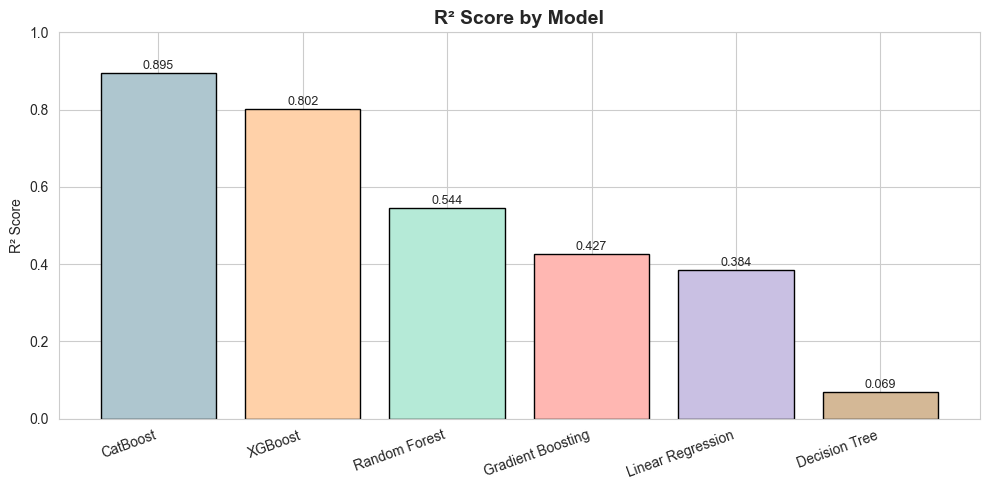

In [25]:
plt.figure(figsize=(10, 5))
colors = ["#AEC6CF", "#FFD1A9", "#B5EAD7", "#FFB7B2", "#C9C0E3", "#D4B896"]
bars   = plt.bar(results["Model"], results["R2"], color=colors, edgecolor="black")
plt.title("R\u00b2 Score by Model", fontsize=14, fontweight="bold")
plt.ylabel("R\u00b2 Score")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
for bar, val in zip(bars, results["R2"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("r2_comparison.png", dpi=150)
plt.show()

### Step 17: Feature Importance

Feature importance from the Random Forest shows which input variables contribute most to the price prediction.

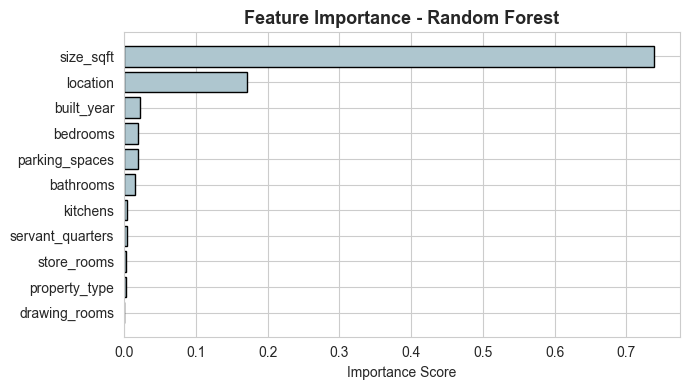

In [26]:
best_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
best_model.fit(X_train, y_train)

importance_df = pd.DataFrame({
    "Feature"   : X.columns,
    "Importance": best_model.feature_importances_
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(7, 4))
plt.barh(importance_df["Feature"], importance_df["Importance"], color="#AEC6CF", edgecolor="black")
plt.title("Feature Importance - Random Forest", fontsize=13, fontweight="bold")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

### Step 18: Actual vs Predicted Plot

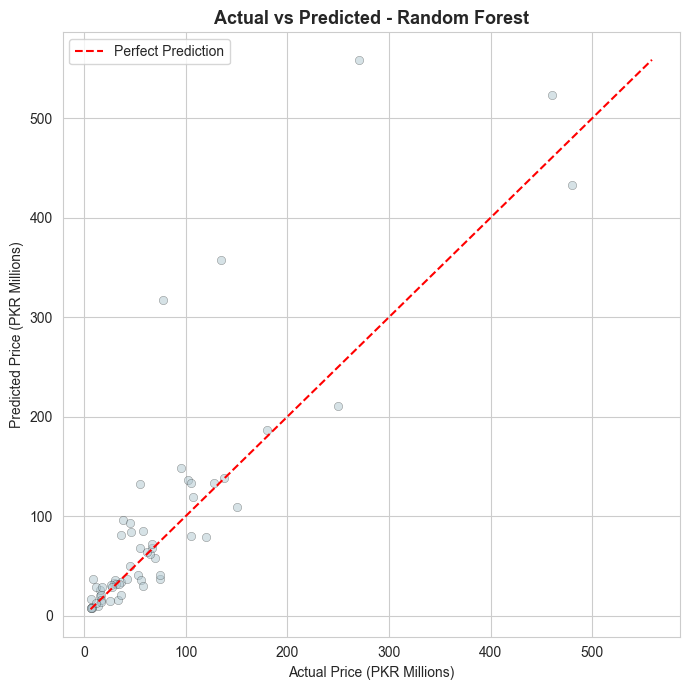

In [27]:
best_preds = best_model.predict(X_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test / 1e6, best_preds / 1e6, alpha=0.5, color="#AEC6CF", edgecolors="k", linewidths=0.3)
lims = [min(y_test.min(), best_preds.min()) / 1e6, max(y_test.max(), best_preds.max()) / 1e6]
plt.plot(lims, lims, "r--", linewidth=1.5, label="Perfect Prediction")
plt.xlabel("Actual Price (PKR Millions)")
plt.ylabel("Predicted Price (PKR Millions)")
plt.title("Actual vs Predicted - Random Forest", fontsize=13, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150)
plt.show()

---
# Task 4: Model Evaluation and Performance Analysis
All six models are evaluated using four standard regression metrics: MAE, MSE, RMSE, and R² Score. Results are visualized and the best model is identified.

### Step 1: Evaluation Function

| Metric | What it measures |
|---|---|
| MAE | Average absolute error in PKR |
| MSE | Squared errors - penalizes large mistakes more |
| RMSE | Square root of MSE - in same units as price |
| R² | Proportion of variance explained by the model |

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)

    mae  = mean_absolute_error(y_te, preds)
    mse  = mean_squared_error(y_te, preds)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_te, preds)

    print(f"\n  {name}")
    print(f"  MAE  : PKR {mae:,.0f}")
    print(f"  MSE  : {mse:,.0f}")
    print(f"  RMSE : PKR {rmse:,.0f}")
    print(f"  R2   : {r2:.4f}")

    return {"Model": name, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2, "preds": preds}

### Step 2: Evaluate All Models

In [29]:
results_list = []

results_list.append(evaluate_model(
    "Linear Regression", LinearRegression(),
    X_train, y_train, X_test, y_test))

results_list.append(evaluate_model(
    "Decision Tree", DecisionTreeRegressor(max_depth=8, random_state=42),
    X_train, y_train, X_test, y_test))

results_list.append(evaluate_model(
    "Random Forest", RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    X_train, y_train, X_test, y_test))

results_list.append(evaluate_model(
    "Gradient Boosting", GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42),
    X_train, y_train, X_test, y_test))

results_list.append(evaluate_model(
    "XGBoost", XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                             subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0),
    X_train, y_train, X_test, y_test))

results_list.append(evaluate_model(
    "CatBoost", CatBoostRegressor(iterations=300, learning_rate=0.05, depth=6, random_seed=42, verbose=0),
    X_train, y_train, X_test, y_test))


  Linear Regression
  MAE  : PKR 39,835,569
  MSE  : 5,159,131,369,961,260
  RMSE : PKR 71,827,094
  R2   : 0.3839

  Decision Tree
  MAE  : PKR 39,611,504
  MSE  : 7,793,257,758,359,497
  RMSE : PKR 88,279,430
  R2   : 0.0694

  Random Forest
  MAE  : PKR 29,655,248
  MSE  : 3,816,076,846,901,390
  RMSE : PKR 61,774,403
  R2   : 0.5443

  Gradient Boosting
  MAE  : PKR 31,753,566
  MSE  : 4,797,309,536,768,454
  RMSE : PKR 69,262,613
  R2   : 0.4271

  XGBoost
  MAE  : PKR 22,811,080
  MSE  : 1,655,786,799,366,144
  RMSE : PKR 40,691,360
  R2   : 0.8023

  CatBoost
  MAE  : PKR 18,582,883
  MSE  : 879,141,700,517,742
  RMSE : PKR 29,650,324
  R2   : 0.8950


### Step 3: Results and Performance Comparison

All metrics are collected into a single DataFrame and sorted by R² Score (highest to lowest).

In [30]:
results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != "preds"}
    for r in results_list
])
results_df = results_df.sort_values("R2", ascending=False).reset_index(drop=True)

display_df = results_df.copy()
display_df["MAE"]  = display_df["MAE"].apply(lambda x: f"PKR {x:,.0f}")
display_df["MSE"]  = display_df["MSE"].apply(lambda x: f"{x:,.0f}")
display_df["RMSE"] = display_df["RMSE"].apply(lambda x: f"PKR {x:,.0f}")
display_df["R2"]   = display_df["R2"].apply(lambda x: f"{x:.4f}")

print(display_df.to_string(index=False))

            Model            MAE                   MSE           RMSE     R2
         CatBoost PKR 18,582,883   879,141,700,517,742 PKR 29,650,324 0.8950
          XGBoost PKR 22,811,080 1,655,786,799,366,144 PKR 40,691,360 0.8023
    Random Forest PKR 29,655,248 3,816,076,846,901,390 PKR 61,774,403 0.5443
Gradient Boosting PKR 31,753,566 4,797,309,536,768,454 PKR 69,262,613 0.4271
Linear Regression PKR 39,835,569 5,159,131,369,961,260 PKR 71,827,094 0.3839
    Decision Tree PKR 39,611,504 7,793,257,758,359,497 PKR 88,279,430 0.0694


### Step 4: Metric Comparison Charts

Four bar charts compare all models across MAE, MSE, RMSE, and R² Score.

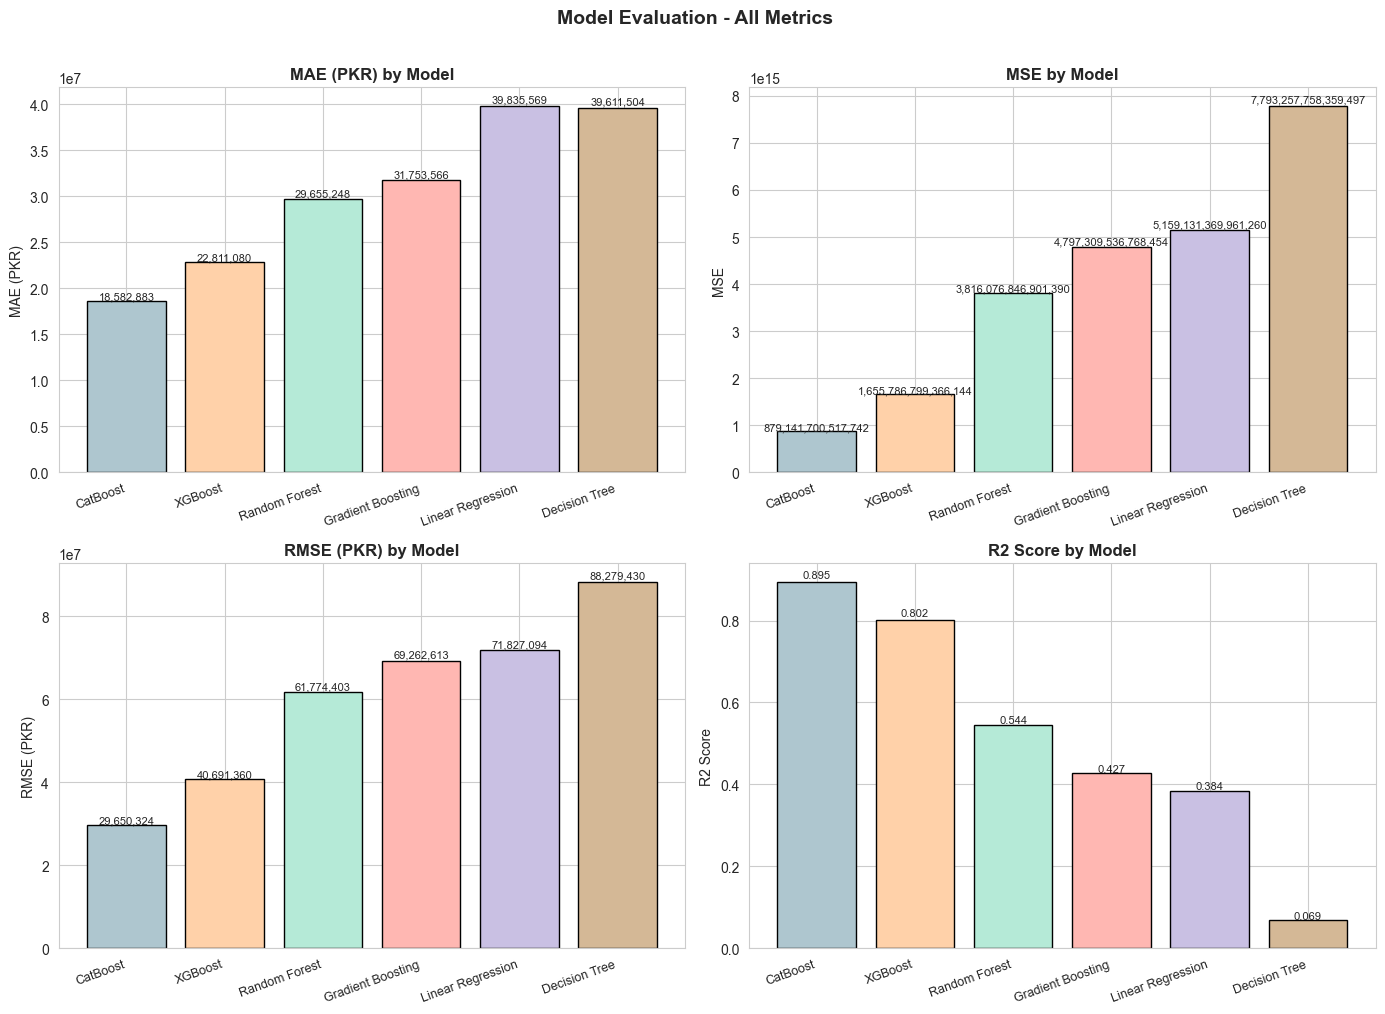

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors  = ["#AEC6CF", "#FFD1A9", "#B5EAD7", "#FFB7B2", "#C9C0E3", "#D4B896"]
models  = results_df["Model"]

metrics = [
    ("MAE",  "MAE (PKR)",  axes[0, 0]),
    ("MSE",  "MSE",        axes[0, 1]),
    ("RMSE", "RMSE (PKR)", axes[1, 0]),
    ("R2",   "R2 Score",   axes[1, 1]),
]

for col, ylabel, ax in metrics:
    bars = ax.bar(models, results_df[col], color=colors, edgecolor="black")
    ax.set_title(f"{ylabel} by Model", fontsize=12, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=20, ha="right", fontsize=9)
    for bar, val in zip(bars, results_df[col]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.01,
                f"{val:,.0f}" if col != "R2" else f"{val:.3f}",
                ha="center", fontsize=8)

plt.suptitle("Model Evaluation - All Metrics", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=150)
plt.show()

### Step 5: Residual Plot

Residuals are the difference between actual and predicted prices. A well-fitted model shows residuals randomly scattered around zero with no systematic pattern.

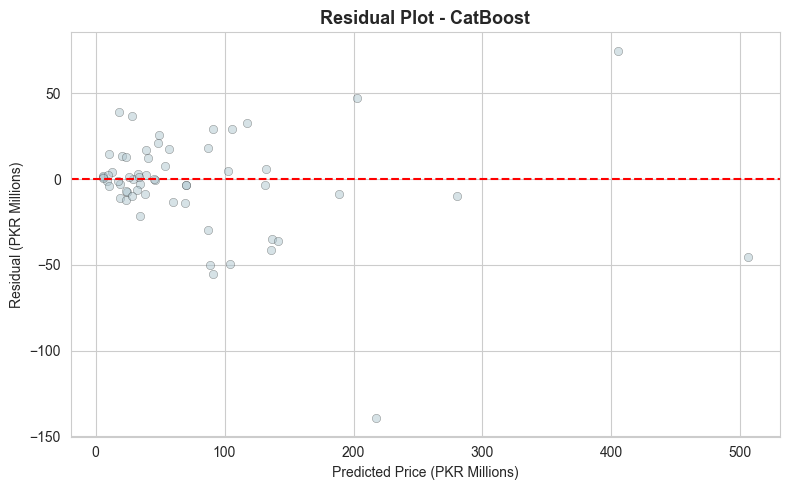

In [32]:
best_row   = results_df.iloc[0]
best_name  = best_row["Model"]
best_preds = next(r["preds"] for r in results_list if r["Model"] == best_name)

residuals = y_test.values - best_preds

plt.figure(figsize=(8, 5))
plt.scatter(best_preds / 1e6, residuals / 1e6, alpha=0.5, color="#AEC6CF", edgecolors="k", linewidths=0.3)
plt.axhline(0, color="red", linestyle="--", linewidth=1.5)
plt.xlabel("Predicted Price (PKR Millions)")
plt.ylabel("Residual (PKR Millions)")
plt.title(f"Residual Plot - {best_name}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("residuals.png", dpi=150)
plt.show()

### Step 6: Best Model Summary

In [33]:
best = results_df.iloc[0]

print("Best Performing Model")
print(f"  Model : {best['Model']}")
print(f"  MAE   : PKR {best['MAE']:,.0f}")
print(f"  MSE   : {best['MSE']:,.0f}")
print(f"  RMSE  : PKR {best['RMSE']:,.0f}")
print(f"  R2    : {best['R2']:.4f}")
print(f"\n{best['Model']} achieved the highest R2 of {best['R2']:.4f},")
print(f"meaning it explains {best['R2']*100:.1f}% of the variance in house prices.")
print(f"On average, predictions are off by PKR {best['MAE']:,.0f}.")

Best Performing Model
  Model : CatBoost
  MAE   : PKR 18,582,883
  MSE   : 879,141,700,517,742
  RMSE  : PKR 29,650,324
  R2    : 0.8950

CatBoost achieved the highest R2 of 0.8950,
meaning it explains 89.5% of the variance in house prices.
On average, predictions are off by PKR 18,582,883.


---
# Task 5: Final Prediction System (CLO-5)
The best model from Task 4 is used to build an interactive prediction system. The user enters property details and the system outputs an estimated house price in PKR.

### Step 1: Identify Best Model from Task 4

In [34]:
best_model_name = results_df.iloc[0]["Model"]
print(f"Best model from Task 4 : {best_model_name}")
print(f"R2   : {results_df.iloc[0]['R2']:.4f}")
print(f"MAE  : PKR {results_df.iloc[0]['MAE']:,.0f}")
print(f"RMSE : PKR {results_df.iloc[0]['RMSE']:,.0f}")

Best model from Task 4 : CatBoost
R2   : 0.8950
MAE  : PKR 18,582,883
RMSE : PKR 29,650,324


### Step 2: Retrain Best Model and Rebuild Location Encoder

The best model is retrained on the training split. A fresh LabelEncoder is fitted on the original location strings so users can enter location names directly.

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

model_map = {
    "Linear Regression" : LinearRegression(),
    "Decision Tree"     : DecisionTreeRegressor(max_depth=8, random_state=42),
    "Random Forest"     : RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    "Gradient Boosting" : GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42),
    "XGBoost"           : XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0),
    "CatBoost"          : CatBoostRegressor(iterations=300, learning_rate=0.05, depth=6, random_seed=42, verbose=0),
}

final_model = model_map[best_model_name]
final_model.fit(X_train, y_train)

df_raw = pd.read_csv("zameen_data.csv")
df_raw = df_raw.dropna(subset=["price_pkr", "size_sqft", "bedrooms", "bathrooms", "location"])

# Rebuild location encoder
location_encoder = LabelEncoder()
location_encoder.fit(df_raw["location"].astype(str))
location_list = sorted(df_raw["location"].unique().tolist())

# Rebuild property_type encoder
property_type_encoder = LabelEncoder()
if "property_type" in df_raw.columns:
    df_raw["property_type"] = df_raw["property_type"].fillna("House")
    property_type_encoder.fit(df_raw["property_type"].astype(str))
    property_type_list = sorted(df_raw["property_type"].unique().tolist())
else:
    property_type_list = []

print(f"{best_model_name} retrained and ready.")
print(f"Total locations available    : {len(location_list)}")
print(f"Total property types available: {len(property_type_list)}")


CatBoost retrained and ready.
Total locations available    : 123
Total property types available: 4


### Step 3: Available Locations

Run this cell to see all valid location names before entering input below.

In [36]:
print("Available Locations")
print("Copy a location name exactly as shown below when prompted.")
print("")
for i, loc in enumerate(location_list, 1):
    print(f"  {i:>3}. {loc}")

Available Locations
Copy a location name exactly as shown below when prompted.

    1. 18 West Residencia, F-11/1
    2. Al-Ghurair Giga - Block 12, Al-Ghurair Giga
    3. Al-Ghurair Giga - Block 16, Al-Ghurair Giga
    4. Al-Ghurair Giga - Block 3, Al-Ghurair Giga
    5. Al-Ghurair Giga - Block 5, Al-Ghurair Giga
    6. Al-Ghurair Giga - Block 8, Al-Ghurair Giga
    7. Al-Ghurair Giga - Block 9, Al-Ghurair Giga
    8. Al-Safa Heights, F-11 Markaz
    9. Arsalan Town, Islamabad
   10. Askari Tower 1, DHA Defence Phase 2
   11. B-17, Islamabad
   12. Bahria Enclave - Sector A, Bahria Enclave
   13. Bahria Enclave - Sector C, Bahria Enclave
   14. Bahria Enclave - Sector C1, Bahria Enclave
   15. Bahria Enclave - Sector H, Bahria Enclave
   16. Bahria Enclave - Sector I, Bahria Enclave
   17. Bahria Enclave - Sector J, Bahria Enclave
   18. Bahria Enclave - Sector N, Bahria Enclave
   19. Bahria Enclave, Bahria Town
   20. Bani Gala, Islamabad
   21. Bhara kahu, Islamabad
   22. Blue Are

### Step 4: Prediction Function

The function accepts area, bedrooms, bathrooms, location, and property type. Location and property type are encoded using the saved encoders before being passed to the model.


In [37]:
def format_pkr(amount):
    if amount >= 10_000_000:
        return f"PKR {amount/10_000_000:.2f} Crore"
    elif amount >= 100_000:
        return f"PKR {amount/100_000:.2f} Lakh"
    else:
        return f"PKR {amount:,.0f}"

def predict_price(area_sqft, bedrooms, bathrooms, location_name, property_type_name="House"):

    # Resolve location
    if location_name not in location_list:
        matches = [l for l in location_list if location_name.lower() in l.lower()]
        if not matches:
            print(f"Location not found: '{location_name}'")
            print("Run Step 3 to see all valid locations.")
            return
        location_name = matches[0]
        print(f"Closest location match used: {location_name}")

    loc_enc = location_encoder.transform([location_name])[0]

    # Resolve property type
    if property_type_list:
        if property_type_name not in property_type_list:
            property_type_name = "House"
            print(f"Property type not recognised, defaulting to: House")
        pt_enc = property_type_encoder.transform([property_type_name])[0]
    else:
        pt_enc = 0

    # Build input row matching X.columns exactly
    row = {}
    for col in X.columns:
        if col == "location":      row[col] = loc_enc
        elif col == "bedrooms":    row[col] = bedrooms
        elif col == "bathrooms":   row[col] = bathrooms
        elif col == "size_sqft":   row[col] = area_sqft
        elif col == "property_type": row[col] = pt_enc
        else:                      row[col] = 0

    input_data = pd.DataFrame([row], columns=X.columns)

    predicted_price = final_model.predict(input_data)[0]
    low  = predicted_price * 0.85
    high = predicted_price * 1.15

    print("")
    print("  HOUSE PRICE PREDICTION SYSTEM")
    print(f"  Model : {best_model_name}")
    print("")
    print("  Input Details")
    print(f"    Area          : {area_sqft:,} sqft  (approx. {area_sqft/225:.1f} Marla)")
    print(f"    Bedrooms      : {bedrooms}")
    print(f"    Bathrooms     : {bathrooms}")
    print(f"    Location      : {location_name}")
    print(f"    Property Type : {property_type_name}")
    print("")
    print("  Estimated Price")
    print(f"    {format_pkr(predicted_price)}")
    print(f"    Raw Value : PKR {predicted_price:,.0f}")
    print("")
    print("  Confidence Range (plus or minus 15 percent)")
    print(f"    Low  : {format_pkr(low)}")
    print(f"    High : {format_pkr(high)}")

print("Prediction function ready.")


Prediction function ready.


### Step 5: Enter Property Details and Get Prediction

Run this cell. You will be prompted to enter values one by one.

**Area reference:**

| Size | Square Feet |
|---|---|
| 5 Marla | 1125 sqft |
| 8 Marla | 1800 sqft |
| 10 Marla | 2250 sqft |
| 1 Kanal | 4500 sqft |

**Valid property types:** House, Flat, Farm House


In [39]:
print("House Price Prediction System")
print("Please enter the property details below.")
print("")

area_sqft          = float(input("Enter Area in sqft (e.g. 1800 for 8 Marla, 4500 for 1 Kanal): "))
bedrooms           = int(input("Enter Number of Bedrooms: "))
bathrooms          = int(input("Enter Number of Bathrooms: "))
location_name      = input("Enter Location (copy from Step 3 list): ")
property_type_name = input("Enter Property Type (House / Flat / Farm House) [default: House]: ").strip() or "House"

predict_price(area_sqft, bedrooms, bathrooms, location_name, property_type_name)


House Price Prediction System
Please enter the property details below.

Closest location match used: I-11, Islamabad

  HOUSE PRICE PREDICTION SYSTEM
  Model : CatBoost

  Input Details
    Area          : 9,000.0 sqft  (approx. 40.0 Marla)
    Bedrooms      : 9
    Bathrooms     : 9
    Location      : I-11, Islamabad
    Property Type : House

  Estimated Price
    PKR 20.11 Crore
    Raw Value : PKR 201,060,562

  Confidence Range (plus or minus 15 percent)
    Low  : PKR 17.09 Crore
    High : PKR 23.12 Crore
